# Risk-Aware Reward Shaping for PPO-Based Portfolio Optimisation

This notebook implements and evaluates a **Proximal Policy Optimisation (PPO)** agent
for stock portfolio management.  The central scientific contribution is the
**formulation of the reward function** with risk-penalty terms whose influence
is studied via a controlled ablation study.

**Dataset**: 8 diverse US stocks (AAPL, MSFT, GOOGL, JPM, XOM, JNJ, AMZN, TSLA)
over 2013-01-01 → 2023-12-31  
**Train split**: 2013-2020 | **Test split**: 2021-2023 (unseen)

---
## Key Enhancements in this Version
1. **Multi-seed training** (5 seeds) for statistical robustness
2. **Decoupled λ/β grid search** (4×4 = 16 configurations)
3. **Stronger baselines**: Equal-weight, Buy-and-hold SPY, Minimum-variance portfolio
4. **Additional metrics**: Calmar Ratio, Sortino Ratio
5. **Portfolio weight visualization** (stacked bar charts)
6. **Market regime breakdown** (bull 2021 / bear 2022)
7. **Transaction costs** in the environment
8. **GPU support** and parallel environments
9. **Bootstrap confidence intervals** on Sharpe Ratio
10. **Full reproducibility** via global seeding

## 0. Install Dependencies

In [1]:
!pip install -q stable-baselines3 gymnasium yfinance pandas numpy matplotlib seaborn

## 0.5 GPU Check & Reproducibility

We set global seeds for full reproducibility and detect the available GPU device.

In [2]:
import torch
import numpy as np
import random

# --- Global seed for reproducibility (Change 10) ---
GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)
torch.manual_seed(GLOBAL_SEED)
random.seed(GLOBAL_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(GLOBAL_SEED)

# --- GPU check (Change 8) ---
if torch.cuda.is_available():
    device = 'cuda'
    print(f'GPU detected: {torch.cuda.get_device_name(0)}')
else:
    device = 'cpu'
    print('No GPU detected — training will run on CPU (slower).')

print(f'Using device: {device}')

GPU detected: NVIDIA GeForce RTX 3050 Laptop GPU
Using device: cuda


## 1. Imports

In [3]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

import gymnasium as gym
from gymnasium import spaces

import yfinance as yf
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, SubprocVecEnv
from stable_baselines3.common.env_util import make_vec_env

print('All imports successful.')

All imports successful.


## 2. Data Collection & Preprocessing

In [4]:
TICKERS = ['AAPL', 'MSFT', 'GOOGL', 'JPM', 'XOM', 'JNJ', 'AMZN', 'TSLA']

raw = yf.download(TICKERS, start='2013-01-01', end='2023-12-31', auto_adjust=True, progress=False)

# Handle both single-level and MultiIndex column structures across yfinance versions
if isinstance(raw.columns, pd.MultiIndex):
    data = raw['Close'].copy()
else:
    data = raw.copy()

# Ensure columns match tickers (reorder for consistency)
data = data[TICKERS]
data = data.dropna()

print(f'Downloaded data shape: {data.shape}  ({data.index[0].date()} → {data.index[-1].date()})')
data.head()

Downloaded data shape: (2768, 8)  (2013-01-02 → 2023-12-29)


Ticker,AAPL,MSFT,GOOGL,JPM,XOM,JNJ,AMZN,TSLA
Date,,,,,,,,
2013-01-02,16.596682,22.192226,17.950983,31.340895,52.043362,48.994320,12.8655,2.357333
2013-01-03,16.387188,21.894941,17.961411,31.277748,51.949509,48.925159,12.9240,2.318000
2013-01-04,15.930736,21.485161,18.316334,31.832144,52.190029,49.485386,12.9575,2.293333
2013-01-07,15.837028,21.444986,18.236414,31.867228,51.585777,49.381626,13.4230,2.289333
2013-01-08,15.879643,21.332506,18.200424,31.930391,51.908428,49.388538,13.3190,2.245333


## 3. Train / Test Split

In [5]:
train_data = data.loc['2013':'2020']
test_data  = data.loc['2021':'2023']

print(f'Train: {train_data.shape[0]} days  ({train_data.index[0].date()} → {train_data.index[-1].date()})')
print(f'Test : {test_data.shape[0]} days  ({test_data.index[0].date()} → {test_data.index[-1].date()})')

Train: 2015 days  (2013-01-02 → 2020-12-31)
Test : 753 days  (2021-01-04 → 2023-12-29)


## 4. Reward Function Formulation

The reward function is the **core contribution** of this work.  At each timestep $t$
the agent receives:

$$
r_t = R_t \;-\; \lambda \cdot R_t^{2} \;-\; \beta \cdot \max(0,\,-R_t)^{2}
$$

where:

| Symbol | Meaning |
|--------|---------|
| $R_t$ | Weighted portfolio return at step $t$ |
| $\lambda$ | **Variance penalty** coefficient — penalises large swings in either direction |
| $\beta$ | **Downside risk** coefficient — extra penalty only when return is negative |

**Intuition**:
- When $\lambda = \beta = 0$ the agent maximises raw return (no risk awareness).
- A non-zero $\lambda$ shrinks the policy toward lower variance (implicit risk control).
- A non-zero $\beta$ adds *asymmetric* loss avoidance: losses are penalised more
  heavily than equivalent gains are rewarded, reflecting real investor preferences.

## 5. Portfolio Environment

The environment now includes a **transaction cost** parameter (Change 7).  
At each step, `transaction_cost × Σ|new_weights − prev_weights|` is subtracted from
the reward to penalise excessive rebalancing. Previous weights are tracked in state.

In [6]:
class PortfolioEnv(gym.Env):
    """
    Custom Gymnasium environment for portfolio optimisation.

    Observation : a flattened (window × n_assets) matrix of *daily returns*
                  (normalised, scale-invariant — suitable for PPO).
    Action      : continuous vector in [-1, 1]^(n_assets+1); softmax-projected
                  to portfolio weights including a cash position.
    Reward      : r_t = R_t - lambda * R_t^2 - beta * max(0, -R_t)^2
                  minus transaction costs (Change 7).
    """

    def __init__(self, price_data: pd.DataFrame, lam: float = 0.1,
                 beta: float = 0.1, window: int = 20,
                 transaction_cost: float = 0.001):
        super().__init__()
        self.prices   = price_data.values.astype(np.float32)
        self.returns  = pd.DataFrame(price_data).pct_change().fillna(0).values.astype(np.float32)
        self.lam      = lam
        self.beta     = beta
        self.window   = window
        self.n_assets = self.prices.shape[1]
        self.T        = len(self.prices)
        self.transaction_cost = transaction_cost  # Change 7

        # Action: raw logits; softmax → weights (incl. cash as last element)
        self.action_space = spaces.Box(
            low=-1.0, high=1.0,
            shape=(self.n_assets + 1,), dtype=np.float32
        )
        # Observation: flattened returns window  (n_assets * window)
        obs_dim = self.n_assets * self.window
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf,
            shape=(obs_dim,), dtype=np.float32
        )

        self.episode_rewards: list = []
        self._ep_reward = 0.0
        self.current_step = self.window
        self.portfolio_value = 1.0
        # Track previous weights for transaction cost calculation (Change 7)
        self.prev_weights = np.ones(self.n_assets, dtype=np.float32) / self.n_assets

    # ------------------------------------------------------------------
    def _get_obs(self) -> np.ndarray:
        """Return the last `window` days of returns, flattened."""
        return self.returns[self.current_step - self.window: self.current_step].flatten()

    # ------------------------------------------------------------------
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step   = self.window
        self.portfolio_value = 1.0
        self._ep_reward     = 0.0
        self.prev_weights = np.ones(self.n_assets, dtype=np.float32) / self.n_assets
        return self._get_obs(), {}

    # ------------------------------------------------------------------
    def step(self, action: np.ndarray):
        # -- Softmax projection to valid weight simplex --
        exp_a   = np.exp(action - action.max())          # numerical stability
        weights = exp_a / exp_a.sum()                    # shape: (n_assets+1,)
        asset_w = weights[:-1]                           # drop cash weight

        # -- Portfolio return at this step --
        step_returns   = self.returns[self.current_step]  # (n_assets,)
        portfolio_ret  = float(np.dot(asset_w, step_returns))

        # -- Reward: r_t = R_t − λ·R_t² − β·max(0,−R_t)² --
        var_penalty      = self.lam  * (portfolio_ret ** 2)
        downside_penalty = self.beta * (max(0.0, -portfolio_ret) ** 2)
        reward = portfolio_ret - var_penalty - downside_penalty

        # -- Transaction cost penalty (Change 7) --
        turnover = np.sum(np.abs(asset_w - self.prev_weights))
        reward -= self.transaction_cost * turnover
        self.prev_weights = asset_w.copy()

        # -- Update portfolio value (compounding) --
        self.portfolio_value *= (1.0 + portfolio_ret)
        self._ep_reward      += reward

        self.current_step += 1
        done = self.current_step >= self.T - 1

        if done:
            self.episode_rewards.append(self._ep_reward)

        obs  = self._get_obs()
        info = {
            'portfolio_value':  self.portfolio_value,
            'portfolio_return': portfolio_ret,
            'reward':           reward,
            'weights':          asset_w.copy(),
        }
        return obs, reward, done, False, info

    def render(self):
        pass


print('PortfolioEnv defined (with transaction costs).')

PortfolioEnv defined (with transaction costs).


## 6. Grid Search — Training PPO Agents (Changes 1, 2, 8)

We perform a **full grid search** over `λ ∈ {0, 0.1, 0.3, 0.5}` and
`β ∈ {0, 0.1, 0.3, 0.5}` independently (Change 2), giving 16 configurations.

Each configuration is trained over **5 random seeds** `[0, 1, 2, 3, 4]` (Change 1)
for statistical rigour. All metrics and plots report **mean ± std** across seeds.

Training uses GPU (`device="cuda"`) and 8 parallel environments (Change 8).

In [7]:

WINDOW = 60  # lookback window for observation
TOTAL_TIMESTEPS = 1_000_000
SEEDS = [0, 1, 2, 3, 4]
LAMBDA_VALUES = [0, 0.1, 0.3, 0.5]
BETA_VALUES   = [0, 0.1, 0.3, 0.5]
N_ENVS = 1  

def make_env(price_data: pd.DataFrame, lam: float = 0.1,
             beta: float = 0.1, window: int = WINDOW,
             transaction_cost: float = 0.001):
    """Factory that returns a callable creating a PortfolioEnv."""
    return lambda: PortfolioEnv(price_data, lam=lam, beta=beta,
                                window=window, transaction_cost=transaction_cost)

Enhanced version: unique model path per run/ skip if already svaed and load already completed models

In [10]:
import os

# --- Multi-seed grid search training loop ---
os.makedirs('./ppo_models', exist_ok=True)
results = {}

total_runs = len(LAMBDA_VALUES) * len(BETA_VALUES) * len(SEEDS)
run_count = 0

for lam in LAMBDA_VALUES:
    for beta in BETA_VALUES:
        key = (lam, beta)
        results[key] = {}
        for seed in SEEDS:
            run_count += 1

            # --- Correct model path per run (includes lam, beta, seed) ---
            #model_path = f"./ppo_models/lam{lam}_beta{beta}_seed{seed}"
            

            # With this (convert decimals to underscores):
            lam_str = str(lam).replace('.', '_')
            beta_str = str(beta).replace('.', '_')
            model_path = f"./ppo_models/lam{lam_str}_beta{beta_str}_seed{seed}"
            rewards_path = model_path + "_rewards.npy"

            # --- Skip if already trained and saved ---
            if os.path.exists(model_path + ".zip"):
                print(f'[{run_count}/{total_runs}] Skipping λ={lam}, β={beta}, seed={seed} — already exists.')
                loaded_rewards = np.load(rewards_path).tolist() if os.path.exists(rewards_path) else []
                results[key][seed] = {
                    'model': PPO.load(model_path, device=device),
                    'env':   None,
                    'episode_rewards': loaded_rewards,
                }
                continue

            print(f'[{run_count}/{total_runs}] Training λ={lam}, β={beta}, seed={seed} …')

            # Set per-run seeds for reproducibility
            np.random.seed(seed)
            torch.manual_seed(seed)

            # Create vectorised environment with N_ENVS parallel envs
            # Changed to use a single environment (Bug Fix - Training episodes too low)
            vec_env = DummyVecEnv([make_env(train_data, lam=lam, beta=beta)])

            policy_kwargs = dict(net_arch=[256, 256])
            model = PPO('MlpPolicy', vec_env, policy_kwargs=policy_kwargs, verbose=0, seed=seed,
                        learning_rate=3e-4, n_steps=2048, batch_size=64,
                        device=device)
            model.learn(total_timesteps=TOTAL_TIMESTEPS)

            # Save immediately after each run with unique path
            model.save(model_path)
            np.save(rewards_path, np.array(vec_env.envs[0].episode_rewards))
            print(f'  ✓ Saved: λ={lam}, β={beta}, seed={seed}')
            print(f"  Rewards saved: {rewards_path}")
            episodes_done = len(vec_env.envs[0].episode_rewards)
            print(f"  Episodes completed: {episodes_done}")

            results[key][seed] = {
                'model': model,
                'env':   vec_env,
                'episode_rewards': vec_env.envs[0].episode_rewards,
            }

print('\nAll training runs complete.')

[1/80] Skipping λ=0, β=0, seed=0 — already exists.
[2/80] Skipping λ=0, β=0, seed=1 — already exists.
[3/80] Skipping λ=0, β=0, seed=2 — already exists.
[4/80] Skipping λ=0, β=0, seed=3 — already exists.
[5/80] Skipping λ=0, β=0, seed=4 — already exists.
[6/80] Skipping λ=0, β=0.1, seed=0 — already exists.
[7/80] Skipping λ=0, β=0.1, seed=1 — already exists.
[8/80] Skipping λ=0, β=0.1, seed=2 — already exists.
[9/80] Skipping λ=0, β=0.1, seed=3 — already exists.
[10/80] Skipping λ=0, β=0.1, seed=4 — already exists.
[11/80] Skipping λ=0, β=0.3, seed=0 — already exists.
[12/80] Skipping λ=0, β=0.3, seed=1 — already exists.
[13/80] Skipping λ=0, β=0.3, seed=2 — already exists.
[14/80] Skipping λ=0, β=0.3, seed=3 — already exists.
[15/80] Skipping λ=0, β=0.3, seed=4 — already exists.
[16/80] Skipping λ=0, β=0.5, seed=0 — already exists.
[17/80] Skipping λ=0, β=0.5, seed=1 — already exists.
[18/80] Skipping λ=0, β=0.5, seed=2 — already exists.
[19/80] Skipping λ=0, β=0.5, seed=3 — already e

## 7. Training Reward Curves

Episode reward trajectories during training reveal how each penalty configuration
affects learning dynamics. We plot three representative configurations:
No-Risk (λ=0,β=0), Moderate (λ=0.1,β=0.1), High-Risk (λ=0.5,β=0.5)
averaged across seeds with ± 1 std shading.

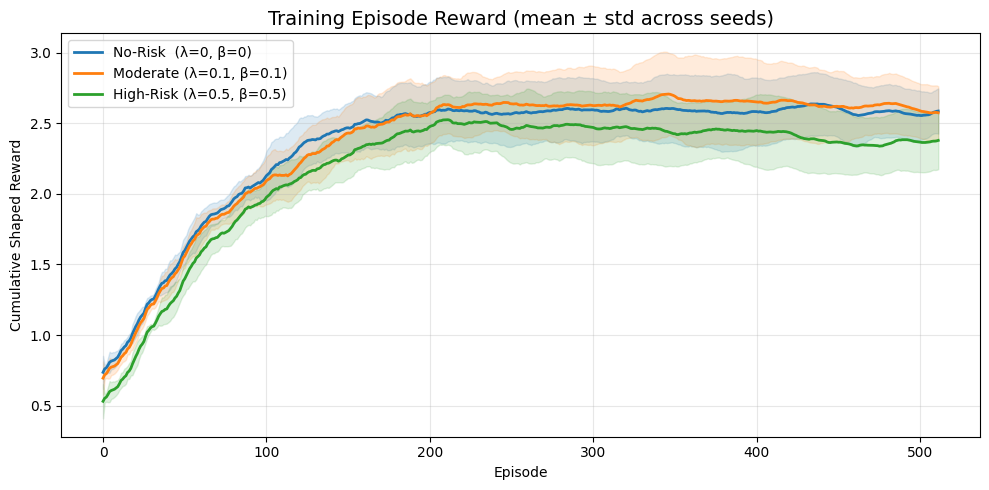

Saved → training_reward_curves.png


In [12]:
def smooth(x, w=10):
    """Simple moving-average smoothing."""
    if len(x) < w:
        return x
    return pd.Series(x).rolling(w, min_periods=1).mean().values

representative_configs = [
    ((0, 0),     'No-Risk  (λ=0, β=0)'),
    ((0.1, 0.1), 'Moderate (λ=0.1, β=0.1)'),
    ((0.5, 0.5), 'High-Risk (λ=0.5, β=0.5)'),
]

colors = ['tab:blue', 'tab:orange', 'tab:green']  # ← added

fig, ax = plt.subplots(figsize=(10, 5))
for idx, (cfg_key, label) in enumerate(representative_configs):  # ← added idx
    all_rewards = []
    for seed in SEEDS:
        env_obj = results[cfg_key][seed]['env']
        if env_obj is None:
            if 'episode_rewards' in results[cfg_key][seed]:
                rews = results[cfg_key][seed]['episode_rewards']
                if rews:
                    all_rewards.append(smooth(rews))
            continue
        else:
            rews = env_obj.envs[0].episode_rewards
            all_rewards.append(smooth(rews))

    if not all_rewards:
        print(f"No training curves available for {label}.")
        continue

    max_len = max(len(r) for r in all_rewards)
    padded = np.full((len(all_rewards), max_len), np.nan)
    for i, r in enumerate(all_rewards):
        padded[i, :len(r)] = r
    mean_r = np.nanmean(padded, axis=0)
    std_r  = np.nanstd(padded, axis=0)
    x = np.arange(max_len)
    ax.plot(x, mean_r, label=label, linewidth=2, color=colors[idx])
    ax.fill_between(x, mean_r - std_r, mean_r + std_r, alpha=0.15, color=colors[idx])

ax.set_title('Training Episode Reward (mean ± std across seeds)', fontsize=14)
ax.set_xlabel('Episode')
ax.set_ylabel('Cumulative Shaped Reward')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('training_reward_curves.png', dpi=150)
plt.show()
print('Saved → training_reward_curves.png')

## 8. Evaluation on Held-Out Test Data (2021-2023)

The evaluation function now also records **portfolio weights at each timestep**
(Change 5) together with portfolio values.

In [ ]:
def evaluate_agent(model, test_df: pd.DataFrame,
                   lam: float = 0.1, beta: float = 0.1,
                   window: int = WINDOW,
                   transaction_cost: float = 0.001):
    """
    Run a trained model on test_df and return the portfolio-value time series
    and the portfolio weights at each step.
    """
    env  = PortfolioEnv(test_df, lam=lam, beta=beta, window=window,
                        transaction_cost=transaction_cost)
    obs, _ = env.reset()
    done   = False

    start_idx = window
    values    = [env.portfolio_value]
    all_weights = []

    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, _, done, _, info = env.step(action)
        values.append(info['portfolio_value'])
        all_weights.append(info['weights'])

    dates  = test_df.index[start_idx: start_idx + len(values)]
    val_series = pd.Series(values[:len(dates)], index=dates)
    weight_df  = pd.DataFrame(all_weights, columns=TICKERS)
    return val_series, weight_df


print('Evaluating all agents on test data …')
eval_results = {}  # eval_results[(lam,beta)][seed] = {'values': ..., 'weights': ...}

for key in results:
    lam, beta = key
    eval_results[key] = {}
    for seed in SEEDS:
        model = results[key][seed]['model']
        vals, wts = evaluate_agent(model, test_data, lam=lam, beta=beta)
        eval_results[key][seed] = {'values': vals, 'weights': wts}

print('Evaluation complete.')

Evaluating all agents on test data …


## 9. Baseline Policies (Change 3)

Three baselines are computed on the test set:
1. **Equal-weight** — divide capital equally across all 8 stocks
2. **Buy-and-hold SPY** — download SPY data for the test period
3. **Minimum-variance portfolio** — classical Markowitz weights from training covariance

In [ ]:
# ── Equal-Weight Baseline ─────────────────────────────────────────────
test_rets = test_data.pct_change().fillna(0)
eq_weights = np.ones(test_data.shape[1]) / test_data.shape[1]
eq_port_ret = test_rets.dot(eq_weights)
val_eq = (1 + eq_port_ret).cumprod()
print(f'Equal-Weight final value: {val_eq.iloc[-1]:.4f}')

# ── Buy-and-Hold SPY Baseline (Change 3) ─────────────────────────────
spy_raw = yf.download('SPY', start=test_data.index[0].strftime('%Y-%m-%d'),
                      end=test_data.index[-1].strftime('%Y-%m-%d'),
                      auto_adjust=True, progress=False)
if isinstance(spy_raw.columns, pd.MultiIndex):
    spy_prices = spy_raw['Close'].squeeze()
else:
    spy_prices = spy_raw['Close']
spy_rets = spy_prices.pct_change().fillna(0)
val_spy = (1 + spy_rets).cumprod()
print(f'Buy-and-Hold SPY final value: {val_spy.iloc[-1]:.4f}')

# ── Minimum-Variance Portfolio Baseline (Change 3) ────────────────────
train_rets = train_data.pct_change().dropna()
cov_matrix = train_rets.cov().values
n = cov_matrix.shape[0]
inv_cov = np.linalg.inv(cov_matrix)
ones = np.ones(n)
mv_weights = inv_cov @ ones / (ones @ inv_cov @ ones)
print(f'Min-Variance weights: {np.round(mv_weights, 4)}')

mv_port_ret = test_rets.dot(mv_weights)
val_mv = (1 + mv_port_ret).cumprod()
print(f'Min-Variance final value: {val_mv.iloc[-1]:.4f}')

## 10. Performance Metrics (Change 4)

Metrics computed for each strategy:

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| Annualised Return | $(V_T)^{252/T} - 1$ | Total growth per year |
| Sharpe Ratio | $\frac{\mu_r \cdot 252}{\sigma_r \cdot \sqrt{252}}$ | Return per unit of risk |
| Max Drawdown | $\min_t \frac{V_t - \max_{s \le t} V_s}{\max_{s \le t} V_s}$ | Worst peak-to-trough loss |
| **Calmar Ratio** | Ann. Return / |Max DD| | Return per unit of drawdown risk |
| **Sortino Ratio** | $\frac{\mu_r \cdot 252}{\sigma_{r^-} \cdot \sqrt{252}}$ | Return per unit of downside risk |

In [ ]:
def compute_metrics(value_series: pd.Series, label: str) -> dict:
    """Compute Sharpe, Sortino, Calmar, Max Drawdown, and Annualised Return."""
    rets = value_series.pct_change().dropna()
    T    = len(rets)

    ann_return = float(value_series.iloc[-1] ** (252 / T) - 1) if T > 0 else np.nan

    sharpe = float((rets.mean() * 252) / (rets.std() * np.sqrt(252))) \
             if rets.std() > 0 else np.nan

    rolling_max = value_series.cummax()
    drawdown    = (value_series - rolling_max) / rolling_max
    max_dd      = float(drawdown.min())

    final_val   = float(value_series.iloc[-1])

    # Calmar Ratio (Change 4)
    calmar = ann_return / abs(max_dd) if abs(max_dd) > 1e-10 else np.nan

    # Sortino Ratio (Change 4)
    neg_rets = rets[rets < 0]
    downside_std = neg_rets.std() if len(neg_rets) > 1 else np.nan
    sortino = float((rets.mean() * 252) / (downside_std * np.sqrt(252))) \
              if downside_std and downside_std > 0 else np.nan

    return {
        'Strategy':            label,
        'Final Value':         round(final_val,   4),
        'Ann. Return (%)':     round(ann_return * 100, 2),
        'Sharpe Ratio':        round(sharpe,       4),
        'Max Drawdown (%)':    round(max_dd * 100, 2),
        'Calmar Ratio':        round(calmar,       4),
        'Sortino Ratio':       round(sortino,      4),
    }

print('compute_metrics defined.')

## 11. Performance Summary (Mean ± Std across Seeds)

All PPO agent metrics are reported as **mean ± std** across the 5 seeds.
Baselines (equal-weight, SPY, min-variance) are deterministic.

In [ ]:
def aggregate_metrics(eval_dict, label):
    """Compute mean ± std of metrics across seeds for one (λ, β) config."""
    all_m = [compute_metrics(eval_dict[s]['values'], label) for s in SEEDS]
    df = pd.DataFrame(all_m)
    agg = {'Strategy': label}
    for col in df.columns:
        if col == 'Strategy':
            continue
        mean_val = df[col].mean()
        std_val  = df[col].std()
        agg[col] = f'{mean_val:.4f} ± {std_val:.4f}'
    return agg

# Build summary table
summary_rows = []

# Baselines (deterministic)
summary_rows.append(compute_metrics(val_eq,  'Equal-Weight Baseline'))
summary_rows.append(compute_metrics(val_spy, 'Buy-and-Hold SPY'))
summary_rows.append(compute_metrics(val_mv,  'Min-Variance Portfolio'))

# PPO agents (representative configs)
for cfg_key, label in representative_configs:
    summary_rows.append(aggregate_metrics(eval_results[cfg_key], f'PPO {label}'))

metrics_df = pd.DataFrame(summary_rows).set_index('Strategy')
print('\n── Performance Summary (Test Set 2021-2023) ──')
print(metrics_df.to_string())
metrics_df

## 12. Sharpe Ratio Heatmap — λ × β Grid (Change 2)

A 4×4 heatmap shows the **mean Sharpe Ratio** (across seeds) for each
combination of λ and β, revealing the interaction between variance penalty
and downside risk penalty.

In [ ]:
# Build Sharpe Ratio matrix
sharpe_matrix = np.zeros((len(LAMBDA_VALUES), len(BETA_VALUES)))

for i, lam in enumerate(LAMBDA_VALUES):
    for j, beta in enumerate(BETA_VALUES):
        key = (lam, beta)
        sharpes = []
        for seed in SEEDS:
            m = compute_metrics(eval_results[key][seed]['values'], '')
            sharpes.append(m['Sharpe Ratio'])
        sharpe_matrix[i, j] = np.nanmean(sharpes)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(sharpe_matrix, annot=True, fmt='.4f',
            xticklabels=[str(b) for b in BETA_VALUES],
            yticklabels=[str(l) for l in LAMBDA_VALUES],
            cmap='RdYlGn', ax=ax)
ax.set_xlabel('β (Downside Risk Penalty)', fontsize=12)
ax.set_ylabel('λ (Variance Penalty)', fontsize=12)
ax.set_title('Mean Sharpe Ratio across Seeds (λ × β Grid)', fontsize=14)
plt.tight_layout()
plt.savefig('sharpe_heatmap.png', dpi=150)
plt.show()
print('Saved → sharpe_heatmap.png')

## 13. Portfolio Value Comparison — Test Period (2021-2023)

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

# Plot baselines
ax.plot(val_eq.index, val_eq.values, label='Equal-Weight', linewidth=1.5, linestyle='--')
ax.plot(val_spy.index, val_spy.values, label='Buy-Hold SPY', linewidth=1.5, linestyle='--')
ax.plot(val_mv.index, val_mv.values, label='Min-Variance', linewidth=1.5, linestyle='--')

# Plot PPO agents (mean ± std band)
colors = ['tab:blue', 'tab:orange', 'tab:green']
for idx, (cfg_key, label) in enumerate(representative_configs):
    all_vals = []
    for seed in SEEDS:
        v = eval_results[cfg_key][seed]['values']
        all_vals.append(v.values)
    # Align lengths
    min_len = min(len(v) for v in all_vals)
    stacked = np.array([v[:min_len] for v in all_vals])
    mean_v = stacked.mean(axis=0)
    std_v  = stacked.std(axis=0)
    dates  = eval_results[cfg_key][SEEDS[0]]['values'].index[:min_len]
    ax.plot(dates, mean_v, label=f'PPO {label}', linewidth=2, color=colors[idx])
    ax.fill_between(dates, mean_v - std_v, mean_v + std_v, alpha=0.15, color=colors[idx])

ax.set_title('Portfolio Value on Test Set (2021-2023)', fontsize=14)
ax.set_ylabel('Portfolio Value (starting = 1.0)')
ax.legend(fontsize=9, loc='best')
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig('portfolio_value_comparison.png', dpi=150)
plt.show()
print('Saved → portfolio_value_comparison.png')

## 14. Portfolio Weight Visualization (Change 5)

For each representative agent, we plot the **average weight allocation per asset**
as a stacked bar chart (averaged across seeds). This shows whether risk-aware agents
are actually more diversified.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for idx, (cfg_key, label) in enumerate(representative_configs):
    # Average weights across seeds
    all_wt_dfs = [eval_results[cfg_key][s]['weights'] for s in SEEDS]
    min_rows = min(len(w) for w in all_wt_dfs)
    stacked_wts = np.stack([w.values[:min_rows] for w in all_wt_dfs], axis=0)
    mean_wts = stacked_wts.mean(axis=0).mean(axis=0)  # mean across seeds, then across time

    ax = axes[idx]
    bottom = 0
    for k, ticker in enumerate(TICKERS):
        ax.bar(0, mean_wts[k], bottom=bottom, label=ticker, width=0.5)
        bottom += mean_wts[k]
    ax.set_title(f'PPO {label}', fontsize=11)
    ax.set_xlim(-0.5, 0.5)
    ax.set_xticks([])
    ax.set_ylabel('Weight' if idx == 0 else '')
    if idx == 2:
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

fig.suptitle('Average Portfolio Weight Allocation per Asset', fontsize=14)
plt.tight_layout()
plt.savefig('weight_allocation.png', dpi=150)
plt.show()
print('Saved → weight_allocation.png')

## 15. Market Regime Breakdown (Change 6)

We split the test period into two sub-periods:
- **Bull market**: 2021-01-01 to 2021-12-31
- **Bear market**: 2022-01-01 to 2022-12-31

All metrics are computed separately for each sub-period.

In [ ]:
def compute_regime_table(regime_label, start_date, end_date):
    """Compute metrics for all strategies within a date range."""
    rows = []

    # Baselines
    for val, name in [(val_eq, 'Equal-Weight'), (val_spy, 'Buy-Hold SPY'), (val_mv, 'Min-Variance')]:
        sub = val.loc[start_date:end_date]
        if len(sub) > 1:
            sub_norm = sub / sub.iloc[0]  # re-normalise to start at 1
            rows.append(compute_metrics(sub_norm, name))

    # PPO agents (mean ± std)
    for cfg_key, label in representative_configs:
        all_m = []
        for seed in SEEDS:
            sub = eval_results[cfg_key][seed]['values'].loc[start_date:end_date]
            if len(sub) > 1:
                sub_norm = sub / sub.iloc[0]
                all_m.append(compute_metrics(sub_norm, f'PPO {label}'))
        if all_m:
            df = pd.DataFrame(all_m)
            agg = {'Strategy': f'PPO {label}'}
            for col in df.columns:
                if col == 'Strategy': continue
                agg[col] = f'{df[col].mean():.4f} ± {df[col].std():.4f}'
            rows.append(agg)

    return pd.DataFrame(rows).set_index('Strategy')

# Bull market
bull_df = compute_regime_table('Bull', '2021-01-01', '2021-12-31')
print('\n── Bull Market (2021) ──')
print(bull_df.to_string())

# Bear market
bear_df = compute_regime_table('Bear', '2022-01-01', '2022-12-31')
print('\n── Bear Market (2022) ──')
print(bear_df.to_string())

## 16. Statistical Significance — Bootstrap CIs (Change 9)

For each agent configuration, we compute a **95% bootstrap confidence interval**
on the Sharpe Ratio using 1000 resamples (numpy only, no additional libraries).

In [ ]:
def bootstrap_ci(data, n_resamples=1000, ci=0.95):
    """Compute bootstrap CI on mean of data using numpy only."""
    rng = np.random.default_rng(GLOBAL_SEED)
    boot_means = np.zeros(n_resamples)
    data = np.array(data)
    for i in range(n_resamples):
        sample = rng.choice(data, size=len(data), replace=True)
        boot_means[i] = np.mean(sample)
    alpha = (1 - ci) / 2
    lo = np.percentile(boot_means, alpha * 100)
    hi = np.percentile(boot_means, (1 - alpha) * 100)
    return np.mean(data), np.std(data), lo, hi

print('\n── Bootstrap 95% CI on Sharpe Ratio ──')
print(f'{"Configuration":<40s} {"Mean":>8s} {"Std":>8s} {"95% CI Low":>12s} {"95% CI High":>12s}')
print('-' * 82)

for lam in LAMBDA_VALUES:
    for beta in BETA_VALUES:
        key = (lam, beta)
        sharpes = []
        for seed in SEEDS:
            m = compute_metrics(eval_results[key][seed]['values'], '')
            sharpes.append(m['Sharpe Ratio'])
        mean_s, std_s, lo, hi = bootstrap_ci(sharpes)
        label = f'λ={lam}, β={beta}'
        print(f'{label:<40s} {mean_s:>8.4f} {std_s:>8.4f} {lo:>12.4f} {hi:>12.4f}')